In [685]:
from pathlib import Path
import sys
import json
import math
import tomllib
import importlib

import cv2
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

ROOT = Path.cwd()
if ROOT.name == 'notebooks':
    ROOT = ROOT.parent

candidates = [ROOT] + list(ROOT.parents)
ROOT = None
for base in candidates:
    if (base / 'src').exists() and (base / 'test_images').exists():
        ROOT = base
        break
if ROOT is None:
    raise RuntimeError('Cannot locate project root (expected src/ and test_images/).')

if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.cam151_ref_detection.homography_preview import build_homography_preview
from src.cam151_ref_detection.roi_store import load_rois
from src.cam151_ref_detection import tube_detection_preview as tube_preview

tube_preview = importlib.reload(tube_preview)

build_tube_detection_preview = tube_preview.build_tube_detection_preview
_pick_detection_roi = tube_preview._pick_detection_roi
_warp_detection_roi = tube_preview._warp_detection_roi
_estimate_stack_band = tube_preview._estimate_stack_band
_normalize_01 = tube_preview._normalize_01
_smooth_1d = tube_preview._smooth_1d
_estimate_dominant_period = tube_preview._estimate_dominant_period
_find_local_peaks_1d = tube_preview._find_local_peaks_1d
_find_best_periodic_peak_run = tube_preview._find_best_periodic_peak_run
_median_period = tube_preview._median_period
_fill_missing_seams = tube_preview._fill_missing_seams
_extend_periodic_seams = tube_preview._extend_periodic_seams
_extend_centers_with_support = tube_preview._extend_centers_with_support
_smooth_x_positions = tube_preview._smooth_x_positions

ARTIFACT_ROOT = ROOT / 'artifacts' / 'notebook_step_by_step'
ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)
print(ROOT)



c:\Users\luis_\OneDrive\Desktop\tenaris_cam_151


## 1. Elegir Imagen

La notebook trabaja por defecto con `cam151_wide_20260323_120028.jpg`, que es una de las imagenes sobre las que hemos estado iterando.

Puedes cambiar `IMG_INDEX` o fijar `IMG_NAME` manualmente.

In [686]:
IMG_PATHS = sorted((ROOT / 'test_images').glob('cam151_*.jpg'))
for idx, path in enumerate(IMG_PATHS):
    print(f'[{idx}] {path.name}')

IMG_INDEX = 3
IMG_NAME = IMG_PATHS[IMG_INDEX].name
IMG_PATH = ROOT / 'test_images' / IMG_NAME
ROI_DIR = ROOT / 'manual_rois'
ROI_DIR.mkdir(parents=True, exist_ok=True)

def resolve_roi_path(root: Path, image_name: str) -> Path:
    stem = Path(image_name).stem
    candidates = [
        root / 'manual_rois' / f'{stem}_rois.toml',
        root / 'manual_rois' / f'{stem}_rois.json',
        root / 'artifacts' / 'manual_rois' / f'{stem}_rois.toml',
        root / 'artifacts' / 'manual_rois' / f'{stem}_rois.json',
        root / 'artifacts' / 'roi_exports' / f'{stem}_rois.toml',
        root / 'artifacts' / 'roi_exports' / f'{stem}_rois.json',
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate
    return candidates[0]

ROI_PATH = resolve_roi_path(ROOT, IMG_NAME)
OUT_DIR = ARTIFACT_ROOT / Path(IMG_NAME).stem
OUT_DIR.mkdir(parents=True, exist_ok=True)

print('IMG_PATH =', IMG_PATH)
print('ROI_PATH =', ROI_PATH)
print('OUT_DIR =', OUT_DIR)



[0] cam151_wide_20260323_100046.jpg
[1] cam151_wide_20260323_102005.jpg
[2] cam151_wide_20260323_103026.jpg
[3] cam151_wide_20260323_120028.jpg
[4] cam151_wide_20260323_140058.jpg
IMG_PATH = c:\Users\luis_\OneDrive\Desktop\tenaris_cam_151\test_images\cam151_wide_20260323_120028.jpg
ROI_PATH = c:\Users\luis_\OneDrive\Desktop\tenaris_cam_151\manual_rois\cam151_wide_20260323_120028_rois.toml
OUT_DIR = c:\Users\luis_\OneDrive\Desktop\tenaris_cam_151\artifacts\notebook_step_by_step\cam151_wide_20260323_120028


In [687]:
def show_bgr(img_or_path, title=None, figsize=(8, 12)):
    if isinstance(img_or_path, (str, Path)):
        img = cv2.imread(str(img_or_path), cv2.IMREAD_COLOR)
        if img is None:
            raise FileNotFoundError(img_or_path)
    else:
        img = img_or_path
    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=figsize)
    plt.imshow(rgb)
    if title:
        plt.title(title)
    plt.axis('off')
    plt.show()


def draw_manual_annotations(image_bgr, rois, points, lines):
    vis = image_bgr.copy()

    for roi in rois:
        x1, y1, x2, y2 = [int(round(v)) for v in roi.get('xyxy', [0, 0, 0, 0])]
        note = str(roi.get('note') or roi.get('id') or 'roi')
        cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 255, 255), 2, cv2.LINE_AA)
        cv2.putText(vis, note[:30], (x1 + 6, max(20, y1 - 8)), cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 255), 2, cv2.LINE_AA)

    for line in lines:
        pts = line.get('points') or line.get('xyxy')
        if pts is None:
            continue
        if isinstance(pts, list) and len(pts) == 4 and isinstance(pts[0], (int, float)):
            x1, y1, x2, y2 = [int(round(v)) for v in pts]
        else:
            (x1, y1), (x2, y2) = pts
            x1, y1, x2, y2 = map(lambda v: int(round(v)), [x1, y1, x2, y2])
        label = str(line.get('label') or line.get('id') or 'line')
        cv2.line(vis, (x1, y1), (x2, y2), (255, 210, 0), 2, cv2.LINE_AA)
        cv2.putText(vis, label[:30], (x1 + 4, max(18, y1 - 4)), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 210, 0), 1, cv2.LINE_AA)

    for point in points:
        x = int(round(point.get('x', 0)))
        y = int(round(point.get('y', 0)))
        label = str(point.get('label') or point.get('kind') or point.get('id') or 'pt')
        cv2.circle(vis, (x, y), 5, (255, 0, 255), -1, cv2.LINE_AA)
        cv2.putText(vis, label[:30], (x + 6, max(18, y - 4)), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 0, 255), 1, cv2.LINE_AA)

    return vis

## 2. Cargar Imagen Y Anotaciones Manuales

Aqui cargamos la imagen original y el archivo de anotaciones exportado desde la app web.

Las anotaciones manuales son la base de dos cosas:
- la homografia,
- la ROI inferior que se usa para sembrar la deteccion de tubos.

Si el archivo no existe todavia para la imagen seleccionada, debes crearlo primero con:
- `python run_roi_web_server.py`
- abrir `http://127.0.0.1:8765/web_roi_picker/`
- guardar ROIs / puntos / lineas para esa imagen



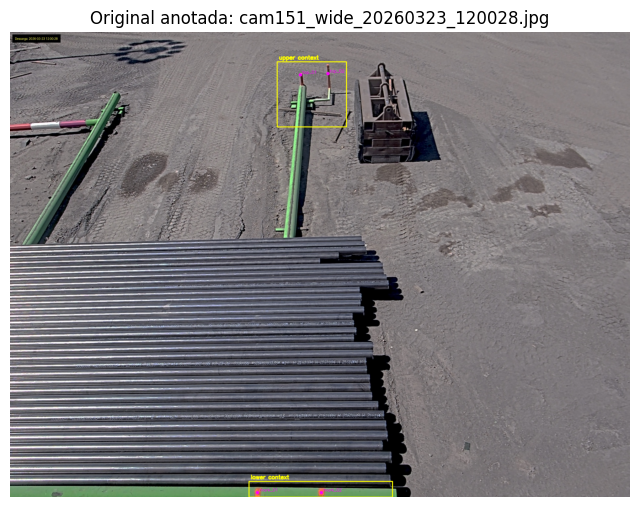

ROIs: 2 | points: 4 | lines: 3


In [688]:
image_bgr = cv2.imread(str(IMG_PATH), cv2.IMREAD_COLOR)
if image_bgr is None:
    raise FileNotFoundError(IMG_PATH)

data = load_rois(ROI_PATH)
rois = data.get('rois', [])
points = data.get('points', [])
lines = data.get('lines', [])

annotated = draw_manual_annotations(image_bgr, rois, points, lines)
show_bgr(annotated, f'Original anotada: {IMG_NAME}', figsize=(8, 12))
print('ROIs:', len(rois), '| points:', len(points), '| lines:', len(lines))

if not ROI_PATH.exists():
    display(Markdown(
        f"**ROI file missing**: `{ROI_PATH}`\n\n"
        f"1. Ejecuta `python run_roi_web_server.py` desde `{ROOT}`.\n"
        f"2. Abre `http://127.0.0.1:8765/web_roi_picker/`.\n"
        f"3. Selecciona `{IMG_NAME}` y guarda ROIs / puntos / lineas.\n"
        f"4. Vuelve a correr esta celda."
    ))
    raise RuntimeError(f'Missing ROI annotations for {IMG_NAME}: {ROI_PATH}')



## 3. Construir La Homografia

La homografia sale de las referencias anotadas en la app.

Actualmente, el constructor puede trabajar de dos formas:
- con guias paralelas (`top_01 -> mark_01`, `top_02 -> mark_02`, `top_ref`, `bottom_horrizontal`),
- o solo con lineas horizontales si no hay suficientes guias.

En nuestro caso estamos usando la primera opcion.

In [689]:
homography = build_homography_preview(
    image_path=IMG_PATH,
    lines=lines,
    points=points,
    output_dir=OUT_DIR / '01_homography',
)

print('src_points =', homography.src_points)
print('output_size =', homography.output_size)
print('overlay =', homography.overlay_path)
print('warp =', homography.warp_path)

src_points = [(950.88671875, 219.84735107421875), (1258.8997802734375, 194.20828247070312), (816.4243774414062, 1526.593994140625), (1304.1180419921875, 1532.947021484375)]
output_size = (478, 1323)
overlay = c:\Users\luis_\OneDrive\Desktop\tenaris_cam_151\artifacts\notebook_step_by_step\cam151_wide_20260323_120028\01_homography\homography_overlay.jpg
warp = c:\Users\luis_\OneDrive\Desktop\tenaris_cam_151\artifacts\notebook_step_by_step\cam151_wide_20260323_120028\01_homography\homography_warp.jpg


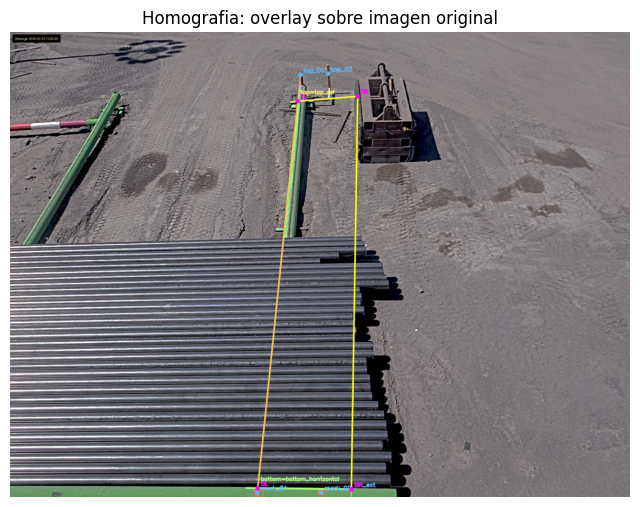

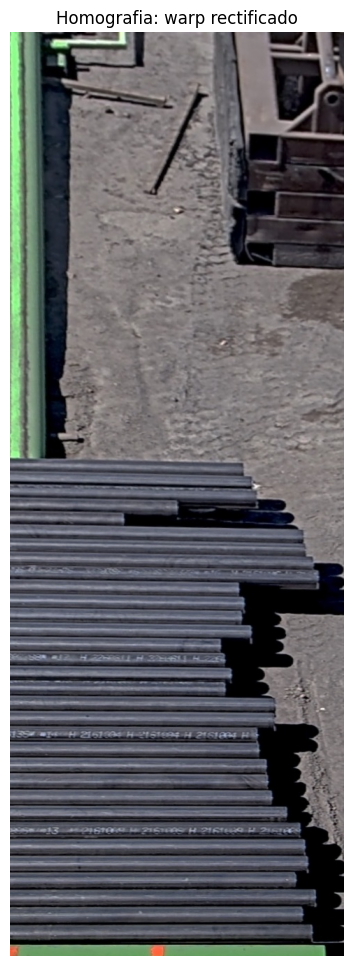

In [690]:
show_bgr(homography.overlay_path, 'Homografia: overlay sobre imagen original', figsize=(8, 12))
show_bgr(homography.warp_path, 'Homografia: warp rectificado', figsize=(8, 12))

## 4. Elegir Y Proyectar La `tube ROI`

No detectamos tubos sobre todo el `warp`. Primero elegimos una ROI inferior anotada manualmente y la proyectamos al `warp`.

Luego la expandimos:
- hacia arriba, para incluir el paquete completo,
- hasta la derecha del `warp`, para no cortar las puntas.

In [691]:
warp_bgr = cv2.imread(str(homography.warp_path), cv2.IMREAD_COLOR)
selected_roi = _pick_detection_roi(rois)
detection_roi = _warp_detection_roi(
    selected_roi,
    homography.src_points,
    homography.output_size,
    warp_bgr.shape,
)
print('selected_roi =', selected_roi)
print('initial detection_roi =', detection_roi)

if detection_roi is not None:
    stack_band = _estimate_stack_band(warp_bgr, detection_roi[0], detection_roi[2])
    print('stack_band =', stack_band)
    if stack_band is not None:
        band_y0, band_y1, run, period = stack_band
        top_expand = max(220, int(round(13.0 * float(period or 22.0))))
        detection_roi = (
            int(detection_roi[0]),
            int(min(detection_roi[1], max(0, band_y0 - top_expand))),
            int(detection_roi[2]),
            int(max(detection_roi[3], band_y1)),
        )

print('expanded detection_roi =', detection_roi)

selected_roi = {'id': 'roi_02', 'note': 'lower context', 'xyxy': [789, 1484, 1263, 1536]}
initial detection_roi = (0, 921, 478, 1323)
stack_band = (592, 1317, [612, 628, 647, 666, 685, 702, 722, 740, 762, 783, 801, 820, 842, 864, 882, 904, 925, 946, 968, 990, 1012, 1034, 1057, 1080, 1103, 1127, 1150, 1175, 1199, 1223, 1248, 1274, 1302], 22.0)
expanded detection_roi = (0, 306, 478, 1323)


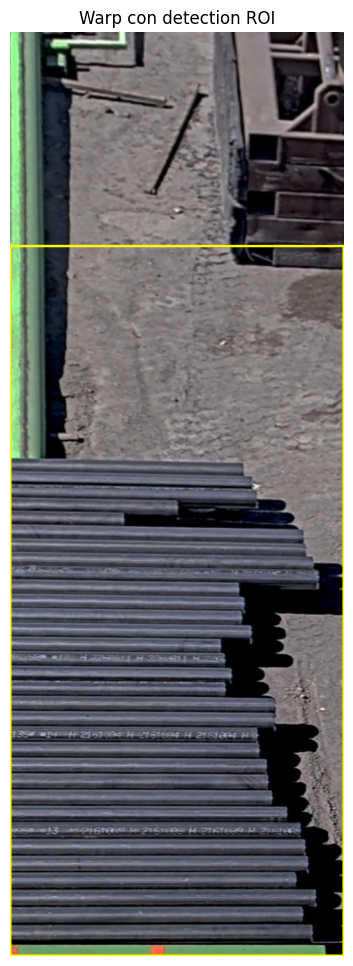

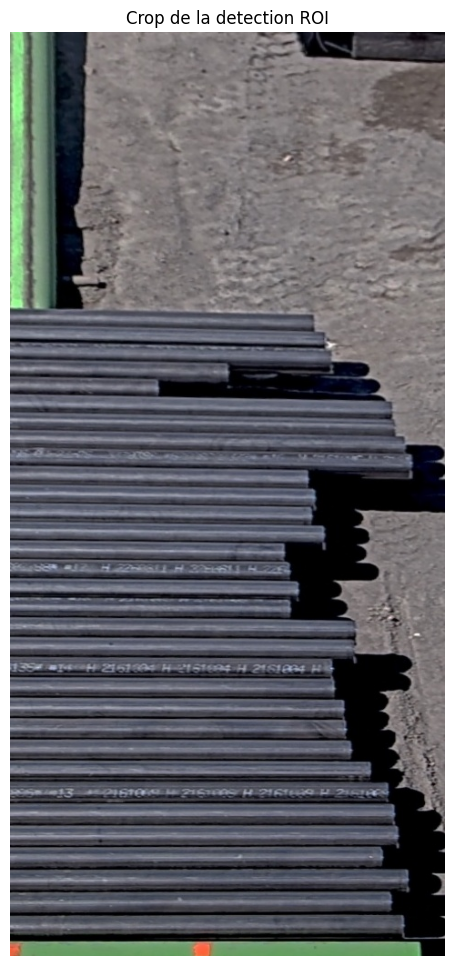

In [692]:
warp_vis = warp_bgr.copy()
if detection_roi is not None:
    x0, y0, x1, y1 = detection_roi
    cv2.rectangle(warp_vis, (x0, y0), (x1 - 1, y1 - 1), (0, 255, 255), 2, cv2.LINE_AA)
show_bgr(warp_vis, 'Warp con detection ROI', figsize=(8, 12))

x0, y0, x1, y1 = detection_roi
warp_crop = warp_bgr[y0:y1, x0:x1].copy()
show_bgr(warp_crop, 'Crop de la detection ROI', figsize=(8, 12))

## 5. Perfil Vertical Para Detectar Filas De Tubos

Aqui empieza la deteccion automatica sobre la ROI del `warp`.

La idea es:
- tomar una franja central de la ROI,
- suavizar horizontalmente,
- construir un perfil de oscuridad por fila,
- estimar el periodo vertical dominante,
- detectar costuras (`seams`) entre tubos.

In [693]:
gray = cv2.cvtColor(warp_crop, cv2.COLOR_BGR2GRAY)
h, w = gray.shape[:2]

strip_x0 = 0
strip_x1 = min(w - 8, max(54, int(round(0.14 * float(w)))))
if strip_x1 <= strip_x0 + 20:
    strip_x0 = 0
    strip_x1 = min(w, max(32, int(round(0.18 * float(w)))))

gray_strip = gray[:, strip_x0:strip_x1]
blur_x = cv2.GaussianBlur(gray_strip, (71, 1), 0)
dark_profile = 255.0 - np.mean(blur_x.astype(np.float32), axis=1)
profile_smooth = _smooth_1d(dark_profile, 9)
profile_norm = _normalize_01(profile_smooth)

strong_rows = np.flatnonzero(profile_norm >= max(0.30, float(np.percentile(profile_norm, 70))))
energy_start_index = int(strong_rows[0]) if strong_rows.size else 0
profile_cut = profile_norm[energy_start_index:]
dominant_period, _autocorr = _estimate_dominant_period(profile_cut, min_period_frac=0.03, max_period_frac=0.18)

base_min_distance = 16
if dominant_period is not None and np.isfinite(dominant_period):
    base_min_distance = max(12, int(round(0.65 * float(dominant_period))))
min_distance_top = max(8, int(round(0.55 * float(base_min_distance))))
min_distance_bottom = max(min_distance_top + 2, int(round(1.00 * float(base_min_distance))))
base_threshold = max(0.32, float(np.percentile(profile_norm, 72)))
first_peak_seed = None
seed_period = float(dominant_period) if dominant_period is not None and np.isfinite(dominant_period) else float(base_min_distance)
seed_lo = min(profile_norm.size - 2, max(1, energy_start_index + 2))
seed_hi = min(profile_norm.size - 2, max(seed_lo + 2, energy_start_index + int(round(0.95 * seed_period))))
first_threshold = min(base_threshold, max(0.18, 0.80 * float(base_threshold)))
seed_candidates = []
for idx in range(seed_lo, seed_hi + 1):
    if profile_norm[idx] >= first_threshold and profile_norm[idx] >= profile_norm[idx - 1] and profile_norm[idx] > profile_norm[idx + 1]:
        seed_candidates.append(int(idx))
if seed_candidates:
    first_peak_seed = int(seed_candidates[0])
else:
    local_seed = profile_norm[seed_lo:seed_hi + 1]
    if local_seed.size:
        seed_arg = int(seed_lo + int(np.argmax(local_seed)))
        if float(profile_norm[seed_arg]) >= max(0.16, 0.70 * float(base_threshold)):
            first_peak_seed = int(seed_arg)
raw_peak_candidates = []
for idx in range(1, profile_norm.size - 1):
    if profile_norm[idx] >= base_threshold and profile_norm[idx] >= profile_norm[idx - 1] and profile_norm[idx] > profile_norm[idx + 1]:
        if idx >= energy_start_index:
            raw_peak_candidates.append(int(idx))

def _local_min_gap(pos_idx: int) -> int:
    denom = max(1.0, float(profile_norm.size - 1 - energy_start_index))
    rel = (float(pos_idx) - float(energy_start_index)) / denom
    rel = min(1.0, max(0.0, rel))
    gap = (1.0 - rel) * float(min_distance_top) + rel * float(min_distance_bottom)
    return max(1, int(round(gap)))

peaks_index = []
for cand in raw_peak_candidates:
    if not peaks_index:
        peaks_index.append(int(cand))
        continue
    gap_needed = _local_min_gap(cand)
    if int(cand) - int(peaks_index[-1]) >= gap_needed:
        peaks_index.append(int(cand))
    elif float(profile_norm[cand]) > float(profile_norm[peaks_index[-1]]):
        peaks_index[-1] = int(cand)
if first_peak_seed is not None:
    if not peaks_index:
        peaks_index = [int(first_peak_seed)]
    else:
        first_gap_needed = max(4, int(round(0.35 * float(min_distance_top))))
        if int(first_peak_seed) < int(peaks_index[0]) and (int(peaks_index[0]) - int(first_peak_seed)) >= first_gap_needed:
            peaks_index = [int(first_peak_seed)] + peaks_index

center_preview_index = []
prev_edge = int(energy_start_index)
min_gap_center = max(6, int(round(0.45 * float(min_distance_top))))
for seam_y in peaks_index:
    seam_y = int(seam_y)
    gap_prev = seam_y - prev_edge
    if gap_prev >= min_gap_center:
        center_preview_index.append(int(round(prev_edge + 0.5 * float(gap_prev))))
    prev_edge = seam_y

print('strip_x0, strip_x1 =', strip_x0, strip_x1)
print('energy_start_index =', energy_start_index)
print('dominant_period =', dominant_period)
print('min_distance_top/bottom =', min_distance_top, min_distance_bottom)
print('first_peak_seed =', first_peak_seed)
print('raw peaks =', peaks_index[:20], '... total =', len(peaks_index))
print('preview centers =', center_preview_index[:20], '... total =', len(center_preview_index))

strip_x0, strip_x1 = 0 67
energy_start_index = 319
dominant_period = 22.0
min_distance_top/bottom = 8 14
first_peak_seed = 322
raw peaks = [322, 341, 360, 379, 396, 416, 434, 456, 477, 495, 514, 536, 558, 576, 598, 619, 640, 662, 684, 706] ... total = 32
preview centers = [332, 350, 370, 388, 406, 425, 445, 466, 486, 504, 525, 547, 567, 587, 608, 630, 651, 673, 695, 717] ... total = 31


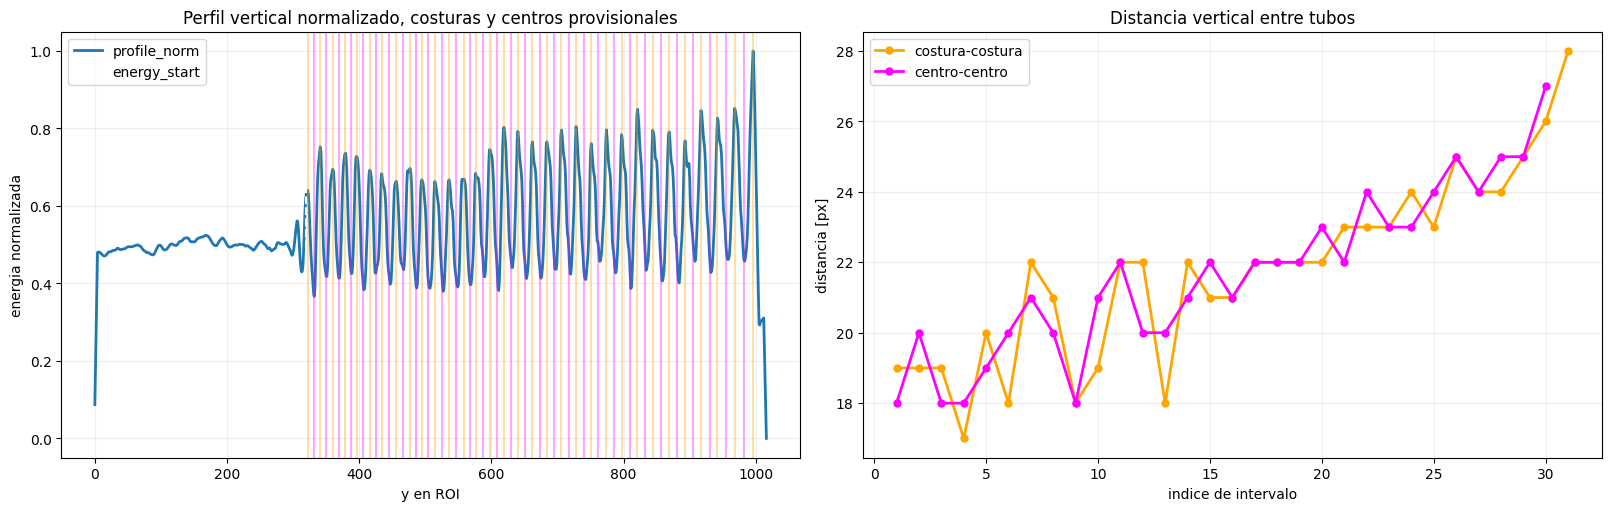

Distancia costura-costura [px]: [19.0, 19.0, 19.0, 17.0, 20.0, 18.0, 22.0, 21.0, 18.0, 19.0, 22.0, 22.0, 18.0, 22.0, 21.0, 21.0, 22.0, 22.0, 22.0, 22.0, 23.0, 23.0, 23.0, 24.0, 23.0, 25.0, 24.0, 24.0, 25.0, 26.0, 28.0]
Cambio entre intervalos costura-costura [px]: [0.0, 0.0, -2.0, 3.0, -2.0, 4.0, -1.0, -3.0, 1.0, 3.0, 0.0, -4.0, 4.0, -1.0, 0.0, 1.0, 0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 1.0, -1.0, 2.0, -1.0, 0.0, 1.0, 1.0, 2.0]
Tendencia costura-costura: aumenta en promedio 0.30 px por intervalo
Distancia centro-centro [px]: [18.0, 20.0, 18.0, 18.0, 19.0, 20.0, 21.0, 20.0, 18.0, 21.0, 22.0, 20.0, 20.0, 21.0, 22.0, 21.0, 22.0, 22.0, 22.0, 23.0, 22.0, 24.0, 23.0, 23.0, 24.0, 25.0, 24.0, 25.0, 25.0, 27.0]
Cambio entre intervalos centro-centro [px]: [2.0, -2.0, 0.0, 1.0, 1.0, 1.0, -1.0, -2.0, 3.0, 1.0, -2.0, 0.0, 1.0, 1.0, -1.0, 1.0, 0.0, 0.0, 1.0, -1.0, 2.0, -1.0, 0.0, 1.0, 1.0, -1.0, 1.0, 0.0, 2.0]
Tendencia centro-centro: aumenta en promedio 0.31 px por intervalo


In [694]:
peaks_arr = np.asarray(peaks_index, np.float32)
centers_arr = np.asarray(center_preview_index, np.float32)
peak_pitch = np.diff(peaks_arr) if peaks_arr.size >= 2 else np.empty((0,), np.float32)
center_pitch = np.diff(centers_arr) if centers_arr.size >= 2 else np.empty((0,), np.float32)
peak_pitch_delta = np.diff(peak_pitch) if peak_pitch.size >= 2 else np.empty((0,), np.float32)
center_pitch_delta = np.diff(center_pitch) if center_pitch.size >= 2 else np.empty((0,), np.float32)

fig, axes = plt.subplots(1, 2, figsize=(16, 5), constrained_layout=True)
ax0, ax1 = axes

y = np.arange(profile_norm.size)
ax0.plot(y, profile_norm, label='profile_norm', lw=2)
ax0.axvline(energy_start_index, color='white', linestyle='--', label='energy_start')
for p in peaks_index:
    ax0.axvline(p, color='orange', alpha=0.35)
for c in center_preview_index:
    ax0.axvline(c, color='magenta', alpha=0.35)
ax0.set_title('Perfil vertical normalizado, costuras y centros provisionales')
ax0.set_xlabel('y en ROI')
ax0.set_ylabel('energia normalizada')
ax0.grid(True, alpha=0.2)
ax0.legend()

if peak_pitch.size:
    peak_idx = np.arange(1, peak_pitch.size + 1)
    ax1.plot(peak_idx, peak_pitch, '-o', color='orange', lw=2, ms=5, label='costura-costura')
if center_pitch.size:
    center_idx = np.arange(1, center_pitch.size + 1)
    ax1.plot(center_idx, center_pitch, '-o', color='magenta', lw=2, ms=5, label='centro-centro')
ax1.set_title('Distancia vertical entre tubos')
ax1.set_xlabel('indice de intervalo')
ax1.set_ylabel('distancia [px]')
ax1.grid(True, alpha=0.2)
if peak_pitch.size or center_pitch.size:
    ax1.legend()

plt.show()

if peak_pitch.size:
    print('Distancia costura-costura [px]:', [round(float(v), 2) for v in peak_pitch.tolist()])
    if peak_pitch_delta.size:
        peak_mean_delta = float(np.mean(peak_pitch_delta))
        peak_dir = 'aumenta' if peak_mean_delta > 0 else 'disminuye' if peak_mean_delta < 0 else 'se mantiene'
        print('Cambio entre intervalos costura-costura [px]:', [round(float(v), 2) for v in peak_pitch_delta.tolist()])
        print(f'Tendencia costura-costura: {peak_dir} en promedio {abs(peak_mean_delta):.2f} px por intervalo')
if center_pitch.size:
    print('Distancia centro-centro [px]:', [round(float(v), 2) for v in center_pitch.tolist()])
    if center_pitch_delta.size:
        center_mean_delta = float(np.mean(center_pitch_delta))
        center_dir = 'aumenta' if center_mean_delta > 0 else 'disminuye' if center_mean_delta < 0 else 'se mantiene'
        print('Cambio entre intervalos centro-centro [px]:', [round(float(v), 2) for v in center_pitch_delta.tolist()])
        print(f'Tendencia centro-centro: {center_dir} en promedio {abs(center_mean_delta):.2f} px por intervalo')


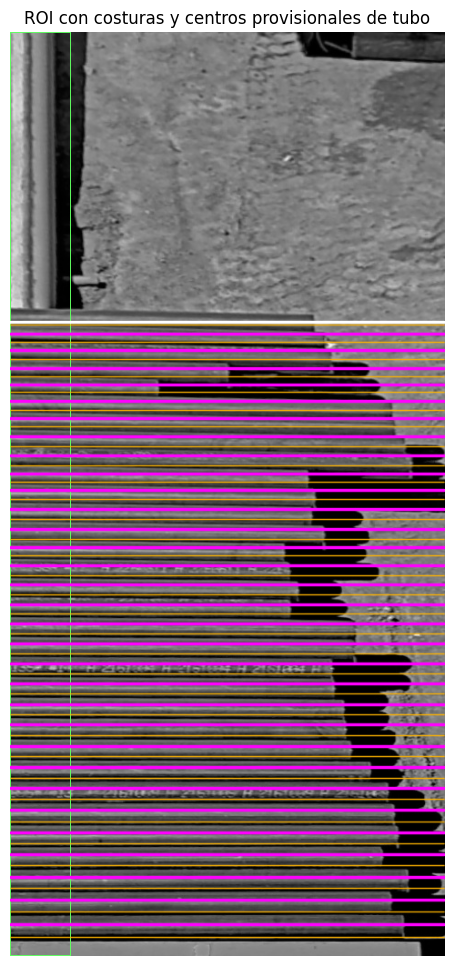

In [695]:
profile_vis = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
cv2.rectangle(profile_vis, (strip_x0, 0), (strip_x1 - 1, h - 1), (96, 255, 96), 1)
cv2.line(profile_vis, (0, energy_start_index), (w - 1, energy_start_index), (255, 255, 255), 2, cv2.LINE_AA)
for p in peaks_index:
    cv2.line(profile_vis, (0, p), (w - 1, p), (0, 180, 255), 1, cv2.LINE_AA)
for c in center_preview_index:
    cv2.line(profile_vis, (0, c), (w - 1, c), (255, 0, 255), 2, cv2.LINE_AA)
show_bgr(profile_vis, 'ROI con costuras y centros provisionales de tubo', figsize=(8, 12))

## 6. Completar Costuras Y Construir Bandas De Tubo

Las costuras candidatas se filtran por periodicidad y se rellenan cuando falta una intermedia.

Con esas costuras se arma cada banda vertical del tubo: borde superior y borde inferior.
Despues `x_start` se busca desde la costura inferior hacia arriba dentro de esa banda.

In [696]:
run_peaks, run_period = _find_best_periodic_peak_run(peaks_index, gap_lo=14, gap_hi=34, min_len=6)
median_period = _median_period(run_peaks or peaks_index)
period_used = run_period or median_period or dominant_period or 22.0

peaks_filled = _fill_missing_seams(run_peaks or peaks_index, period_used)
peaks_filled = _extend_periodic_seams(
    peaks_filled,
    peaks_index,
    period_used,
    profile_norm,
    y_min=max(0, energy_start_index - int(round(0.6 * float(period_used)))),
    y_max=int(profile_norm.size - 1),
)

lo_gap = max(12.0, 0.55 * float(period_used))
hi_gap = max(lo_gap + 1.0, 1.55 * float(period_used))
tube_top_rows_list = []
tube_bottom_rows_list = []
if peaks_filled:
    top_gap = float(peaks_filled[0] - energy_start_index)
    if lo_gap <= top_gap <= hi_gap:
        tube_top_rows_list.append(int(energy_start_index))
        tube_bottom_rows_list.append(int(peaks_filled[0]))
for prev, curr in zip(peaks_filled[:-1], peaks_filled[1:]):
    gap = float(curr - prev)
    if lo_gap <= gap <= hi_gap:
        tube_top_rows_list.append(int(prev))
        tube_bottom_rows_list.append(int(curr))

tube_top_rows = np.asarray(tube_top_rows_list, np.int32)
tube_bottom_rows = np.asarray(tube_bottom_rows_list, np.int32)
tube_heights = tube_bottom_rows - tube_top_rows

print('period_used =', period_used)
print('run_peaks[:10] =', run_peaks[:10])
print('peaks_filled[:20] =', peaks_filled[:20])
print('tube_top_rows[:12] =', tube_top_rows[:12].tolist())
print('tube_bottom_rows[:12] =', tube_bottom_rows[:12].tolist())
print('tube_heights[:12] =', tube_heights[:12].tolist())
print('tube band count =', len(tube_bottom_rows))

period_used = 22.0
run_peaks[:10] = [322, 341, 360, 379, 396, 416, 434, 456, 477, 495]
peaks_filled[:20] = [322, 341, 360, 379, 396, 416, 434, 456, 477, 495, 514, 536, 558, 576, 598, 619, 640, 662, 684, 706]
tube_top_rows[:12] = [322, 341, 360, 379, 396, 416, 434, 456, 477, 495, 514, 536]
tube_bottom_rows[:12] = [341, 360, 379, 396, 416, 434, 456, 477, 495, 514, 536, 558]
tube_heights[:12] = [19, 19, 19, 17, 20, 18, 22, 21, 18, 19, 22, 22]
tube band count = 31


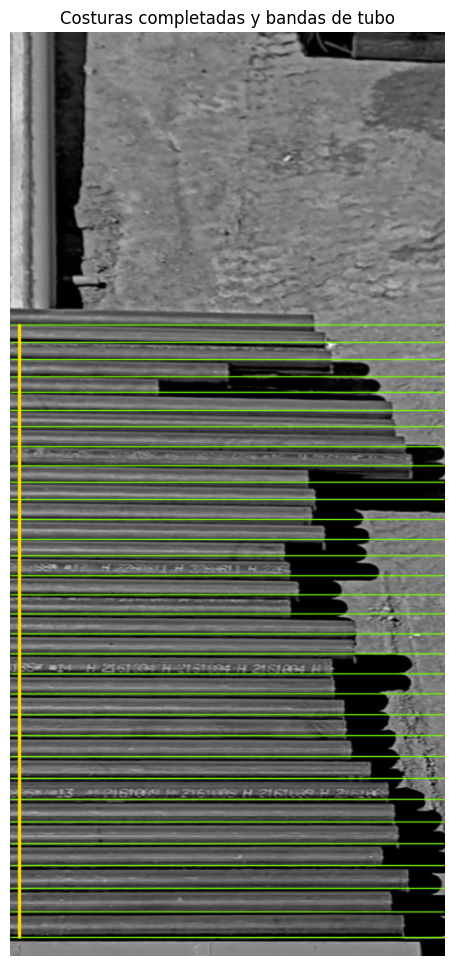

In [697]:
bands_vis = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
for p in peaks_filled:
    cv2.line(bands_vis, (0, int(p)), (w - 1, int(p)), (0, 255, 120), 1, cv2.LINE_AA)
for y_top, y_bot in zip(tube_top_rows, tube_bottom_rows):
    cv2.line(bands_vis, (10, int(y_top)), (10, int(y_bot)), (0, 220, 255), 2, cv2.LINE_AA)
show_bgr(bands_vis, 'Costuras completadas y bandas de tubo', figsize=(8, 12))

## 7. Estimacion Inicial Del Extremo Derecho (`x_start`) Con Sobel X Por ROI

Antes del refinamiento fino, el recorrido manual ahora hace una estimacion gruesa asi:
- tomar cada ROI vertical del tubo entre costuras verdes,
- extender la ventana mas hacia la izquierda para no recortar tubos,
- aplicar un blur configurable dentro de cada ROI,
- correr `Sobel X` sobre cada ROI ya suavizado,
- colapsar ese `Sobel X` a un perfil 1D en `x`,
- y escoger el candidato mas a la izquierda que siga siendo consistente con los puntos vecinos.

El debug de esta seccion muestra el ROI, el blur, el Sobel X y el perfil 1D usados para decidir el punto.

In [698]:
# Fixed blur for this step.
blur_kernel = (21, 1)

x_search0 = max(int(round(0.32 * float(w))), strip_x0)
x_search1 = max(x_search0 + 8, min(w, int(round(0.98 * float(w)))))

roi_keep_frac = 5.0 / 8.0

raw_x_positions = []
raw_hit_rows = []
roi_boxes = []
roi_debug_panels = []
for idx, (y_top, y_bot) in enumerate(zip(tube_top_rows, tube_bottom_rows), start=1):
    y0_full = max(0, int(y_top))
    y1 = min(gray.shape[0] - 1, int(y_bot))
    band_h = max(1, int(y1 - y0_full + 1))
    roi_h = max(3, min(band_h, int(round(roi_keep_frac * float(band_h)))))
    y0 = max(y0_full, int(y1 - roi_h + 1))
    fallback_x = float(raw_x_positions[-1]) if raw_x_positions else float(x_search0)
    hit_y = int(round(0.5 * float(y0 + y1)))
    x_pick = float(fallback_x)
    use_neg_edge = True
    roi_boxes.append((int(y0), int(y1)))
    roi_gray = gray[y0:y1 + 1, x_search0:x_search1]
    if roi_gray.size == 0:
        raw_x_positions.append(float(x_pick))
        raw_hit_rows.append(int(hit_y))
        continue
    roi_blur = cv2.GaussianBlur(roi_gray, blur_kernel, 0)
    roi_grad_x = cv2.Sobel(roi_blur.astype(np.float32), cv2.CV_32F, 1, 0, ksize=3)
    roi_grad_x_pos = np.maximum(roi_grad_x, 0.0)
    roi_grad_x_neg = np.maximum(-roi_grad_x, 0.0)
    roi_sobel_abs = np.abs(roi_grad_x).astype(np.float32)
    roi_sobel_abs = roi_sobel_abs - float(np.min(roi_sobel_abs))
    sobel_abs_den = float(np.max(roi_sobel_abs))
    if sobel_abs_den > 1e-6:
        roi_sobel_abs = roi_sobel_abs / sobel_abs_den
    else:
        roi_sobel_abs = np.zeros_like(roi_grad_x, np.float32)
    profile_raw = np.max(roi_sobel_abs, axis=0).astype(np.float32)
    profile_1d = np.power(_normalize_01(_smooth_1d(profile_raw, 9)), 2.0) if profile_raw.size else np.empty((0,), np.float32)
    x_local = None
    if profile_1d.size and float(np.max(profile_1d)) > 1e-6:
        peak_threshold = max(0.18, 0.45 * float(np.max(profile_1d)))
        cand_x = _find_local_peaks_1d(profile_1d, threshold=peak_threshold, min_distance=5)
        if cand_x:
            x_local = int(min(cand_x))
        else:
            x_local = int(np.argmax(profile_1d))
    if x_local is not None:
        neg_strength = float(np.max(roi_grad_x_neg[:, x_local])) if roi_grad_x_neg.shape[0] > 0 else 0.0
        pos_strength = float(np.max(roi_grad_x_pos[:, x_local])) if roi_grad_x_pos.shape[0] > 0 else 0.0
        if neg_strength >= max(1e-6, 0.75 * pos_strength):
            edge_col = roi_grad_x_neg[:, x_local].astype(np.float32)
            use_neg_edge = True
        else:
            edge_col = roi_grad_x_pos[:, x_local].astype(np.float32)
            use_neg_edge = False
        edge_col = edge_col - float(np.min(edge_col))
        edge_den = float(np.max(edge_col))
        if edge_den > 1e-6:
            edge_col = edge_col / edge_den
        else:
            edge_col = np.zeros_like(edge_col, np.float32)
        cand_rows = np.flatnonzero(edge_col >= max(0.30, 0.70 * float(np.max(edge_col))))
        ref_rel_y = None
        if raw_hit_rows:
            ref_rel_y = float(np.median(np.asarray(raw_hit_rows[-3:], np.float32))) - float(y0)
        if cand_rows.size == 0:
            hit_local_y = int(np.argmax(edge_col)) if edge_col.size else int(round(0.5 * float(y1 - y0)))
        else:
            best_y_score = -1e9
            hit_local_y = int(cand_rows[0])
            for cand_y in cand_rows.tolist():
                top_bonus = 1.0 - (float(cand_y) / max(1.0, float(edge_col.size - 1)))
                consistency_y = 0.0
                if ref_rel_y is not None:
                    consistency_y = max(0.0, 1.0 - abs(float(cand_y) - ref_rel_y) / max(4.0, 0.35 * float(edge_col.size)))
                y_score = (1.00 * top_bonus) + (0.55 * consistency_y) + (0.25 * float(edge_col[cand_y]))
                if y_score > best_y_score:
                    best_y_score = y_score
                    hit_local_y = int(cand_y)
        hit_y = int(y0 + hit_local_y)
        x_pick = float(x_search0 + x_local)
    raw_x_positions.append(float(x_pick))
    raw_hit_rows.append(int(hit_y))
    raw_patch = cv2.cvtColor(roi_gray, cv2.COLOR_GRAY2BGR)
    blur_patch = cv2.cvtColor(roi_blur, cv2.COLOR_GRAY2BGR)
    sobel_u8 = np.uint8(np.clip(255.0 * roi_sobel_abs, 0, 255))
    sobel_patch = cv2.cvtColor(sobel_u8, cv2.COLOR_GRAY2BGR)
    profile_patch = np.zeros_like(raw_patch)
    if profile_1d.size:
        pts = []
        for xx, val in enumerate(profile_1d.tolist()):
            yy = int(round((1.0 - float(val)) * max(0, profile_patch.shape[0] - 1)))
            pts.append((int(xx), yy))
        if len(pts) >= 2:
            cv2.polylines(profile_patch, [np.asarray(pts, np.int32)], False, (255, 255, 255), 1, cv2.LINE_AA)
    xl = max(0, min(raw_patch.shape[1] - 1, int(round(x_pick - x_search0))))
    yl = max(0, min(raw_patch.shape[0] - 1, int(hit_y - y0)))
    text_y = max(10, min(raw_patch.shape[0] - 3, 12))
    blur_label = f'blur{blur_kernel[0]}x{blur_kernel[1]}'
    for patch, label in ((raw_patch, 'raw'), (blur_patch, blur_label), (sobel_patch, 'sobelX_abs'), (profile_patch, 'profile1D')):
        cv2.line(patch, (xl, 0), (xl, patch.shape[0] - 1), (0, 255, 255), 1, cv2.LINE_AA)
        cv2.circle(patch, (xl, yl), 2, (0, 255, 255), -1, cv2.LINE_AA)
        cv2.putText(patch, label, (4, text_y), cv2.FONT_HERSHEY_SIMPLEX, 0.38, (255, 255, 255), 1, cv2.LINE_AA)
    pair = np.hstack([raw_patch, blur_patch, sobel_patch, profile_patch])
    edge_tag = 'neg' if use_neg_edge else 'pos'
    cv2.putText(pair, f'#{idx} {edge_tag}', (4, max(12, text_y)), cv2.FONT_HERSHEY_SIMPLEX, 0.40, (0, 255, 255), 1, cv2.LINE_AA)
    roi_debug_panels.append(pair)

raw_pick_x_positions = list(raw_x_positions)
raw_x_positions = _smooth_x_positions(raw_x_positions)
probe_rows = np.asarray(raw_hit_rows, np.int32)

roi_overlay_vis = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
cv2.rectangle(roi_overlay_vis, (x_search0, 0), (x_search1 - 1, h - 1), (96, 255, 96), 1)
for idx, ((y0, y1), y_hit, x_pick) in enumerate(zip(roi_boxes, probe_rows, raw_pick_x_positions), start=1):
    x_i = int(round(x_pick))
    cv2.rectangle(roi_overlay_vis, (x_search0, int(y0)), (x_search1 - 1, int(y1)), (0, 220, 255), 1)
    cv2.line(roi_overlay_vis, (x_search0, int(y0)), (x_search1 - 1, int(y0)), (0, 0, 255), 1, cv2.LINE_AA)
    cv2.line(roi_overlay_vis, (x_i, int(y1)), (x_i, int(y_hit)), (0, 255, 255), 1, cv2.LINE_AA)
    cv2.circle(roi_overlay_vis, (x_i, int(y_hit)), 2, (0, 255, 255), -1, cv2.LINE_AA)
    cv2.putText(roi_overlay_vis, str(idx), (x_search0 + 4, max(12, int(y0) + 12)), cv2.FONT_HERSHEY_SIMPLEX, 0.35, (255, 255, 255), 1, cv2.LINE_AA)

roi_debug_sheet = None
if roi_debug_panels:
    max_h = max(panel.shape[0] for panel in roi_debug_panels)
    max_w = max(panel.shape[1] for panel in roi_debug_panels)
    padded = []
    for panel in roi_debug_panels:
        canvas = np.zeros((max_h, max_w, 3), np.uint8)
        canvas[:panel.shape[0], :panel.shape[1]] = panel
        padded.append(canvas)
    roi_debug_sheet = np.vstack(padded)

print('probe_rows[:12] =', probe_rows[:12].tolist())
print('raw_x_positions[:12] =', [round(v, 1) for v in raw_x_positions[:12]])
print('roi_count =', len(roi_boxes))
print('blur_kernel =', blur_kernel)

probe_rows[:12] = [330, 352, 373, 390, 404, 423, 443, 467, 490, 511, 530, 551]
raw_x_positions[:12] = [347.0, 347.0, 241.0, 241.0, 412.0, 420.0, 424.0, 424.0, 336.0, 333.0, 336.0, 333.0]
roi_count = 31
blur_kernel = (21, 1)


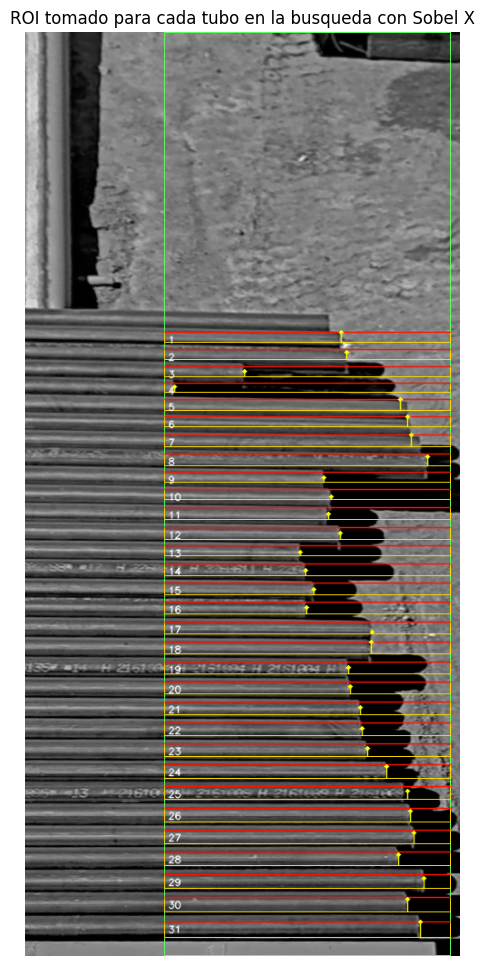

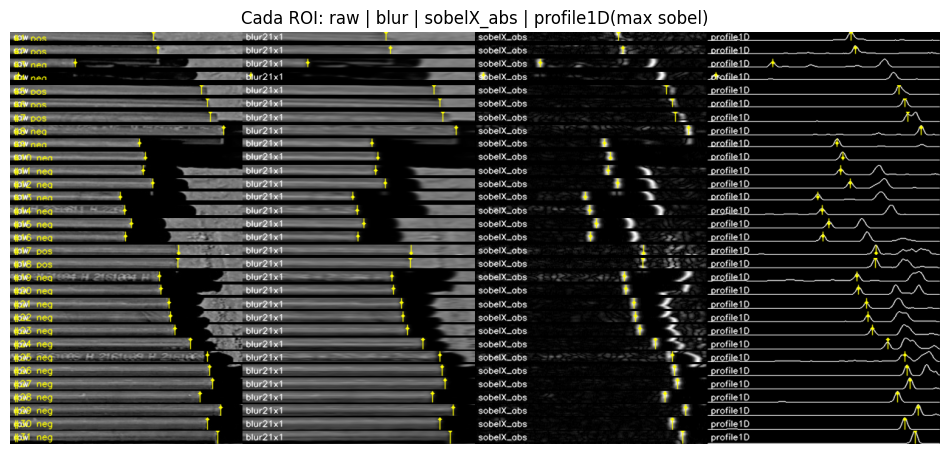

In [699]:
show_bgr(roi_overlay_vis, 'ROI tomado para cada tubo en la busqueda con Sobel X', figsize=(8, 12))
if roi_debug_sheet is not None:
    sheet_h = max(12, 1.10 * float(len(roi_debug_panels)))
    show_bgr(roi_debug_sheet, 'Cada ROI: raw | blur | sobelX_abs | profile1D(max sobel)', figsize=(12, sheet_h))

## 8. Refinamiento Por Zoom

Quitamos el pipeline viejo de Canny / curve / SAM2.

Ahora el refinamiento hace un segundo pase local por tubo:
1. toma una ROI horizontal mas chica alrededor de cada `raw_x_positions`,
2. aplica `GaussianBlur(1, 101)`,
3. vuelve a calcular `Sobel X`,
4. construye `profile1D(max sobel)`,
5. toma el pico valido mas a la izquierda,
6. y al final solo suaviza una vez la lista de `x`.

In [700]:
zoom_blur_kernel = (1, 101)
zoom_half_width = 30
zoom_min_width = 28
zoom_half_height_min = 14

zoom_seed_x_positions = list(raw_pick_x_positions)
zoom_x_positions = []
zoom_confidences = []
zoom_roi_boxes = []
zoom_debug_panels = []

for idx, ((y0, y1), x_seed, y_hit) in enumerate(zip(roi_boxes, zoom_seed_x_positions, probe_rows), start=1):
    y0_band = max(0, int(y0))
    y1_band = min(gray.shape[0] - 1, int(y1))
    band_h = max(1, int(y1_band - y0_band + 1))
    zoom_half_height = max(zoom_half_height_min, int(round(0.35 * float(band_h))))
    hit_i = int(round(float(y_hit)))
    y0i = max(y0_band, hit_i - zoom_half_height)
    y1i = min(y1_band, hit_i + zoom_half_height)
    if y1i <= y0i + 8:
        y0i = y0_band
        y1i = y1_band
    seed_i = int(round(float(x_seed)))
    zoom_width = max(zoom_min_width, int(2 * zoom_half_width + 1))
    zx0 = int(round(float(seed_i) - float(zoom_half_width)))
    zx1 = int(round(float(seed_i) + float(zoom_half_width) + 1.0))
    if zx0 < int(x_search0):
        shift = int(x_search0) - zx0
        zx0 += shift
        zx1 += shift
    if zx1 > int(x_search1):
        shift = zx1 - int(x_search1)
        zx0 -= shift
        zx1 -= shift
    zx0 = max(int(x_search0), zx0)
    zx1 = min(int(x_search1), zx1)
    if zx1 <= zx0 + zoom_min_width:
        deficit = zoom_min_width - (zx1 - zx0)
        zx0 = max(int(x_search0), zx0 - int(round(0.50 * float(deficit))))
        zx1 = min(int(x_search1), zx1 + int(round(0.50 * float(deficit))))
    if zx1 <= zx0 + 8:
        zoom_x_positions.append(float(x_seed))
        zoom_confidences.append(0.0)
        zoom_roi_boxes.append((y0i, y1i, zx0, zx1))
        continue

    roi_gray_zoom = gray[y0i:y1i + 1, zx0:zx1]
    if roi_gray_zoom.size == 0:
        zoom_x_positions.append(float(x_seed))
        zoom_confidences.append(0.0)
        zoom_roi_boxes.append((y0i, y1i, zx0, zx1))
        continue

    roi_blur_zoom = cv2.GaussianBlur(roi_gray_zoom, zoom_blur_kernel, 0)
    roi_grad_x_zoom = cv2.Sobel(roi_blur_zoom.astype(np.float32), cv2.CV_32F, 1, 0, ksize=3)
    roi_sobel_abs_zoom = np.abs(roi_grad_x_zoom).astype(np.float32)
    roi_sobel_abs_zoom = roi_sobel_abs_zoom - float(np.min(roi_sobel_abs_zoom))
    sobel_den = float(np.max(roi_sobel_abs_zoom))
    if sobel_den > 1e-6:
        roi_sobel_abs_zoom = roi_sobel_abs_zoom / sobel_den
    else:
        roi_sobel_abs_zoom = np.zeros_like(roi_sobel_abs_zoom, np.float32)

    profile_raw = np.max(roi_sobel_abs_zoom, axis=0).astype(np.float32)
    profile_1d = np.power(_normalize_01(_smooth_1d(profile_raw, 9)), 2.0) if profile_raw.size else np.empty((0,), np.float32)

    x_local = None
    conf_val = 0.0
    if profile_1d.size and float(np.max(profile_1d)) > 1e-6:
        peak_threshold = max(0.16, 0.55 * float(np.max(profile_1d)))
        cand_x = _find_local_peaks_1d(profile_1d, threshold=peak_threshold, min_distance=3)
        if cand_x:
            cand_arr = np.asarray(cand_x, np.int32)
            x_local = int(cand_arr[int(np.argmax(profile_1d[cand_arr]))])
        else:
            x_local = int(np.argmax(profile_1d))
        conf_val = float(profile_1d[x_local])

    x_pick = float(x_seed) if x_local is None else float(zx0 + x_local)
    zoom_x_positions.append(float(x_pick))
    zoom_confidences.append(float(conf_val))
    zoom_roi_boxes.append((y0i, y1i, zx0, zx1))

    raw_patch = cv2.cvtColor(roi_gray_zoom, cv2.COLOR_GRAY2BGR)
    blur_patch = cv2.cvtColor(roi_blur_zoom, cv2.COLOR_GRAY2BGR)
    sobel_u8 = np.uint8(np.clip(255.0 * roi_sobel_abs_zoom, 0, 255))
    sobel_patch = cv2.cvtColor(sobel_u8, cv2.COLOR_GRAY2BGR)
    profile_patch = np.zeros_like(raw_patch)
    if profile_1d.size:
        pts = []
        for xx, val in enumerate(profile_1d.tolist()):
            yy = int(round((1.0 - float(val)) * max(0, profile_patch.shape[0] - 1)))
            pts.append((int(xx), yy))
        if len(pts) >= 2:
            cv2.polylines(profile_patch, [np.asarray(pts, np.int32)], False, (255, 255, 255), 1, cv2.LINE_AA)

    seed_local_x = max(0, min(raw_patch.shape[1] - 1, int(round(float(x_seed) - float(zx0)))))
    pick_local_x = max(0, min(raw_patch.shape[1] - 1, int(round(float(x_pick) - float(zx0)))))
    pick_local_y = max(0, min(raw_patch.shape[0] - 1, int(round(float(y_hit) - float(y0i)))))
    for patch in (raw_patch, blur_patch, sobel_patch, profile_patch):
        cv2.line(patch, (seed_local_x, 0), (seed_local_x, patch.shape[0] - 1), (255, 255, 0), 1, cv2.LINE_AA)
        cv2.line(patch, (pick_local_x, 0), (pick_local_x, patch.shape[0] - 1), (0, 255, 255), 1, cv2.LINE_AA)
        cv2.circle(patch, (pick_local_x, pick_local_y), 2, (0, 255, 255), -1, cv2.LINE_AA)
    pair = np.hstack([raw_patch, blur_patch, sobel_patch, profile_patch])
    cv2.putText(pair, f'#{idx}', (4, 9), cv2.FONT_HERSHEY_SIMPLEX, 0.24, (0, 255, 255), 1, cv2.LINE_AA)
    zoom_debug_panels.append(pair)

refine_x_positions = list(zoom_x_positions)
local_confidences = list(zoom_confidences)
final_x_positions = list(refine_x_positions)
final_x_positions = [
    float(min(max(x_val, float(zx0)), float(max(zx0, zx1 - 1))))
    for x_val, (_y0i, _y1i, zx0, zx1) in zip(final_x_positions, zoom_roi_boxes)
]

compare_old_new_vis = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
for p in peaks_filled:
    cv2.line(compare_old_new_vis, (0, int(p)), (w - 1, int(p)), (0, 255, 120), 1, cv2.LINE_AA)
for idx, ((y0_band, y1_band), x_old, x_new, y_probe) in enumerate(zip(roi_boxes, zoom_seed_x_positions, refine_x_positions, probe_rows), start=1):
    y0v = max(0, int(y0_band))
    y1v = min(compare_old_new_vis.shape[0] - 1, int(y1_band))
    xo = int(round(float(x_old)))
    xn = int(round(float(x_new)))
    yp = int(round(float(y_probe)))
    cv2.line(compare_old_new_vis, (xo, y0v), (xo, y1v), (255, 255, 0), 1, cv2.LINE_AA)
    cv2.line(compare_old_new_vis, (xn, y0v), (xn, y1v), (0, 0, 255), 1, cv2.LINE_AA)
    cv2.circle(compare_old_new_vis, (xo, yp), 2, (255, 255, 0), -1, cv2.LINE_AA)
    cv2.circle(compare_old_new_vis, (xn, yp), 2, (0, 0, 255), -1, cv2.LINE_AA)
    cv2.putText(compare_old_new_vis, str(idx), (max(0, xo - 10), max(12, y0v + 12)), cv2.FONT_HERSHEY_SIMPLEX, 0.32, (255, 255, 255), 1, cv2.LINE_AA)

final_smooth_vis = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
for p in peaks_filled:
    cv2.line(final_smooth_vis, (0, int(p)), (w - 1, int(p)), (0, 255, 120), 1, cv2.LINE_AA)
for idx, ((y0_band, y1_band), x_zoom, x_final, y_probe) in enumerate(zip(roi_boxes, refine_x_positions, final_x_positions, probe_rows), start=1):
    y0v = max(0, int(y0_band))
    y1v = min(final_smooth_vis.shape[0] - 1, int(y1_band))
    xz = int(round(float(x_zoom)))
    xf = int(round(float(x_final)))
    yp = int(round(float(y_probe)))
    cv2.line(final_smooth_vis, (xz, y0v), (xz, y1v), (0, 255, 255), 1, cv2.LINE_AA)
    cv2.line(final_smooth_vis, (xf, y0v), (xf, y1v), (0, 0, 255), 1, cv2.LINE_AA)
    cv2.circle(final_smooth_vis, (xz, yp), 2, (0, 255, 255), -1, cv2.LINE_AA)
    cv2.circle(final_smooth_vis, (xf, yp), 2, (0, 0, 255), -1, cv2.LINE_AA)

zoom_overlay_vis = cv2.cvtColor(gray, cv2.COLOR_GRAY2BGR)
for p in peaks_filled:
    cv2.line(zoom_overlay_vis, (0, int(p)), (w - 1, int(p)), (0, 255, 120), 1, cv2.LINE_AA)
for idx, ((y0i, y1i, zx0, zx1), x_seed, x_zoom, x_final, conf_val) in enumerate(zip(zoom_roi_boxes, zoom_seed_x_positions, refine_x_positions, final_x_positions, local_confidences), start=1):
    cv2.rectangle(zoom_overlay_vis, (int(zx0), int(y0i)), (int(zx1 - 1), int(y1i)), (0, 220, 255), 1)
    cv2.line(zoom_overlay_vis, (int(zx0), int(y0i)), (int(zx1 - 1), int(y0i)), (0, 0, 255), 1, cv2.LINE_AA)
    cv2.line(zoom_overlay_vis, (int(round(x_seed)), int(y0i)), (int(round(x_seed)), int(y1i)), (255, 255, 0), 1, cv2.LINE_AA)
    color_zoom = (0, 0, 255) if float(conf_val) < 0.30 else (0, 255, 255)
    cv2.line(zoom_overlay_vis, (int(round(x_zoom)), int(y0i)), (int(round(x_zoom)), int(y1i)), color_zoom, 1, cv2.LINE_AA)
    cv2.line(zoom_overlay_vis, (int(round(x_final)), int(y0i)), (int(round(x_final)), int(y1i)), (0, 0, 255), 1, cv2.LINE_AA)
    cv2.putText(zoom_overlay_vis, str(idx), (int(zx0) + 4, max(12, int(y0i) + 12)), cv2.FONT_HERSHEY_SIMPLEX, 0.35, (255, 255, 255), 1, cv2.LINE_AA)

zoom_debug_sheet = None
if zoom_debug_panels:
    max_h = max(panel.shape[0] for panel in zoom_debug_panels)
    max_w = max(panel.shape[1] for panel in zoom_debug_panels)
    padded = []
    for panel in zoom_debug_panels:
        canvas = np.zeros((max_h, max_w, 3), np.uint8)
        canvas[:panel.shape[0], :panel.shape[1]] = panel
        padded.append(canvas)
    zoom_debug_sheet = np.vstack(padded)

print('zoom_blur_kernel =', zoom_blur_kernel)
print('zoom_seed_x_positions[:12] =', [round(v, 1) for v in zoom_seed_x_positions[:12]])
print('refine_x_positions[:12]    =', [round(v, 1) for v in refine_x_positions[:12]])
print('final_x_positions[:12]     =', [round(v, 1) for v in final_x_positions[:12]])
print('local_confidences[:12]     =', [round(v, 2) for v in local_confidences[:12]])

zoom_blur_kernel = (1, 101)
zoom_seed_x_positions[:12] = [347.0, 353.0, 241.0, 164.0, 412.0, 420.0, 424.0, 442.0, 328.0, 336.0, 333.0, 346.0]
refine_x_positions[:12]    = [344.0, 354.0, 238.0, 161.0, 417.0, 420.0, 433.0, 440.0, 327.0, 334.0, 333.0, 344.0]
final_x_positions[:12]     = [344.0, 354.0, 238.0, 161.0, 417.0, 420.0, 433.0, 440.0, 327.0, 334.0, 333.0, 344.0]
local_confidences[:12]     = [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]


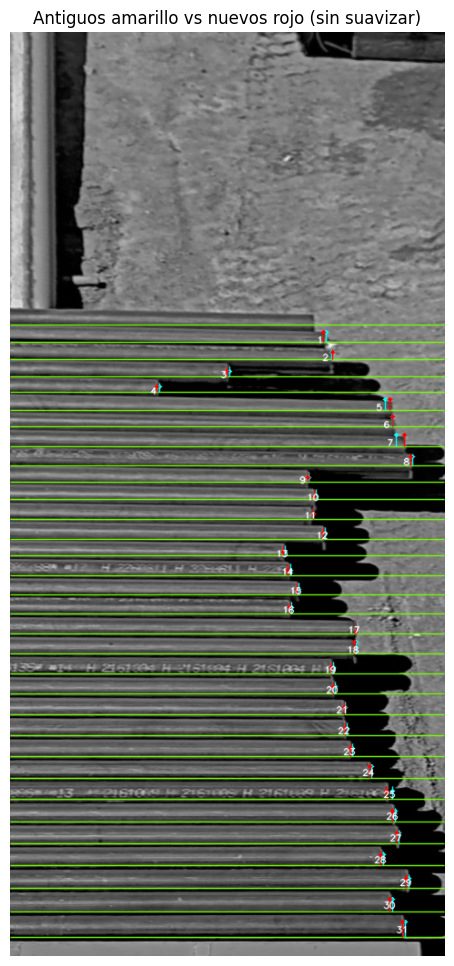

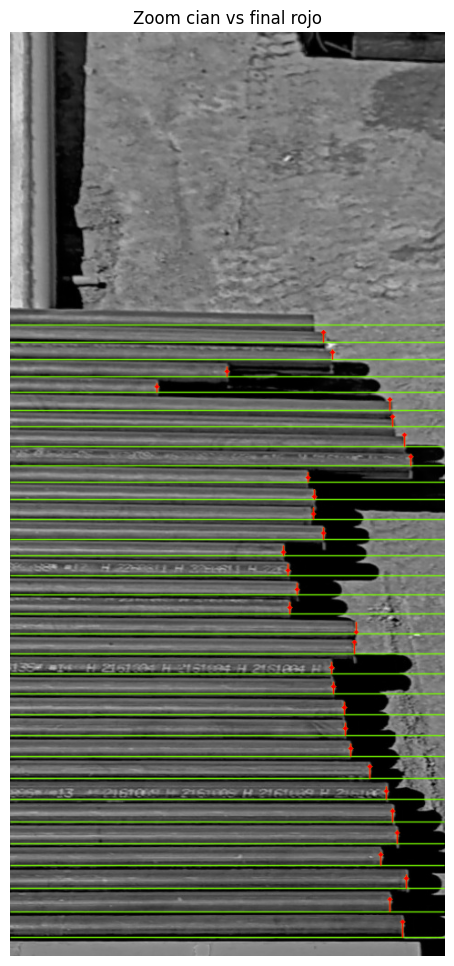

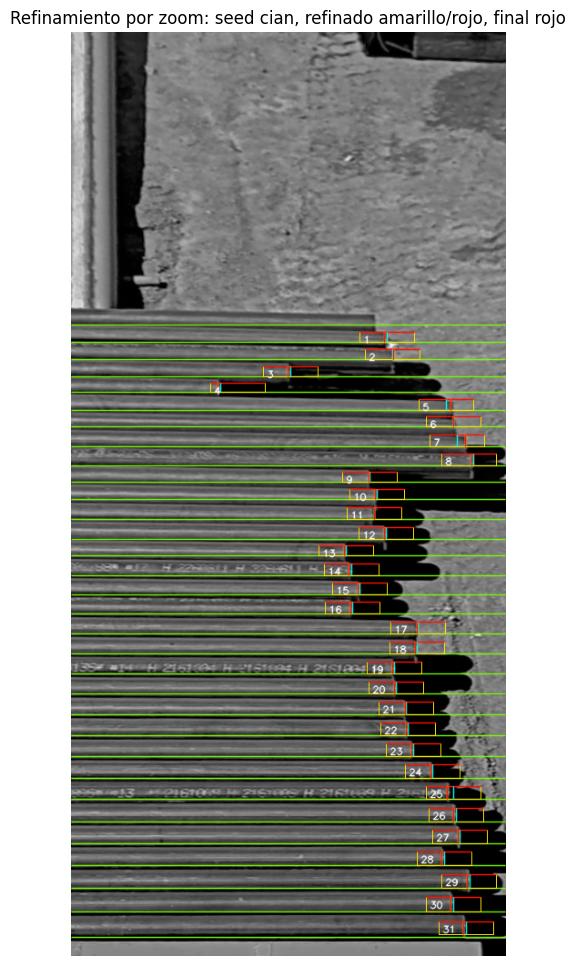

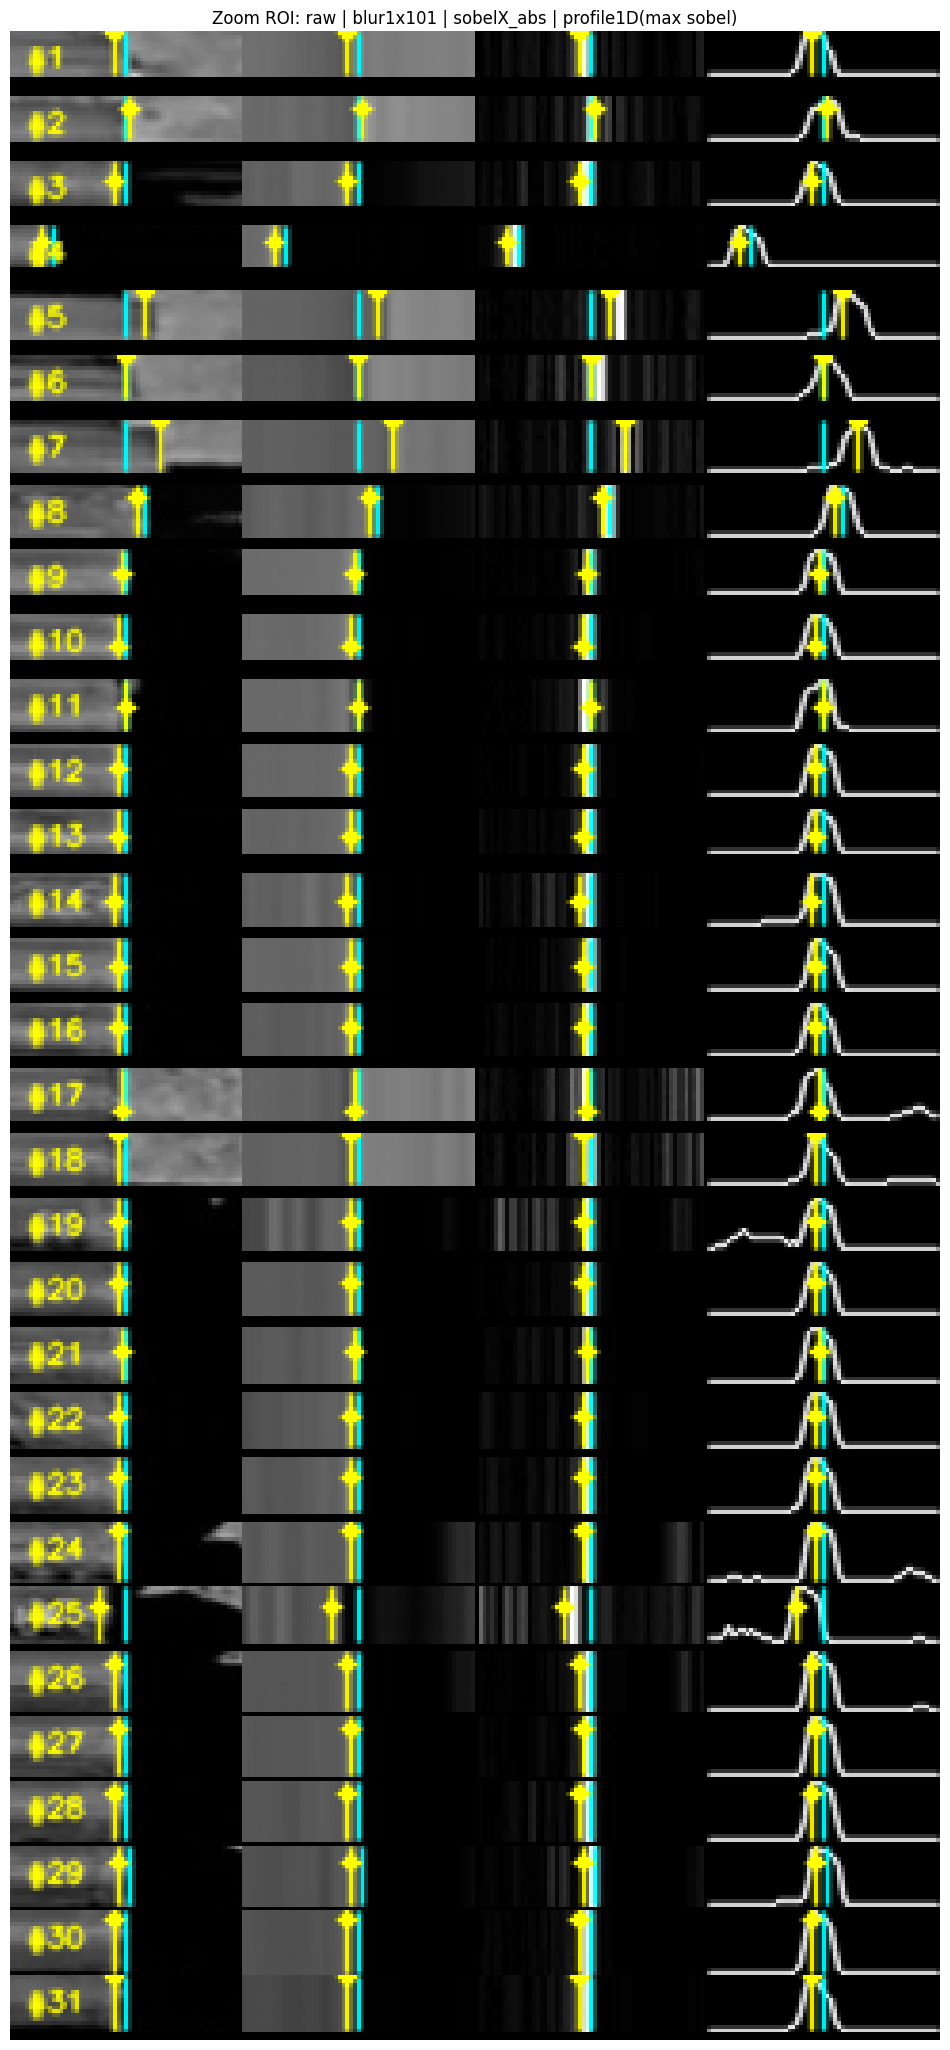

In [701]:
show_bgr(compare_old_new_vis, 'Antiguos amarillo vs nuevos rojo (sin suavizar)', figsize=(8, 12))
show_bgr(final_smooth_vis, 'Zoom cian vs final rojo', figsize=(8, 12))
show_bgr(zoom_overlay_vis, 'Refinamiento por zoom: seed cian, refinado amarillo/rojo, final rojo', figsize=(8, 12))
if zoom_debug_sheet is not None:
    sheet_h = max(12, 1.10 * float(len(zoom_debug_panels)))
    show_bgr(zoom_debug_sheet, 'Zoom ROI: raw | blur1x101 | sobelX_abs | profile1D(max sobel)', figsize=(12, sheet_h))

## 9. Resultado Final Del Pipeline

Esta celda ejecuta la funcion de alto nivel `build_tube_detection_preview(...)`.
Hoy sirve solo como referencia, porque la funcion de alto nivel todavia conserva la logica vieja basada en centros.

In [702]:
result = build_tube_detection_preview(
    image_path=IMG_PATH,
    lines=lines,
    points=points,
    rois=rois,
    output_dir=OUT_DIR / '02_final_preview',
)

print('tube_count =', result.tube_count)
print('dominant_period =', result.dominant_period)
print('energy_start_index =', result.energy_start_index)
print('detection_roi =', result.detection_roi)
print('overlay =', result.detection_overlay_path)

tube_count = 31
dominant_period = 22.0
energy_start_index = 625
detection_roi = (0, 306, 478, 1323)
overlay = c:\Users\luis_\OneDrive\Desktop\tenaris_cam_151\artifacts\notebook_step_by_step\cam151_wide_20260323_120028\02_final_preview\tube_detection_warp.jpg


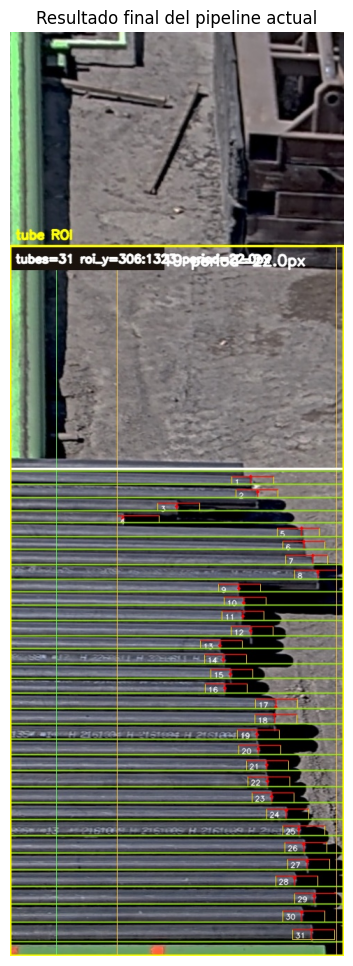

In [703]:
show_bgr(result.detection_overlay_path, 'Resultado final del pipeline actual', figsize=(8, 12))

## 10. Ventanas Locales De Los Primeros Tubos

Estas ventanas son utiles para diagnosticar por que fallan los tubos altos.

En la practica, la mayor parte de los errores residuales se concentran aqui:
- tubos parciales de arriba,
- sombra muy marcada a la derecha,
- poco contexto del cuerpo del tubo.

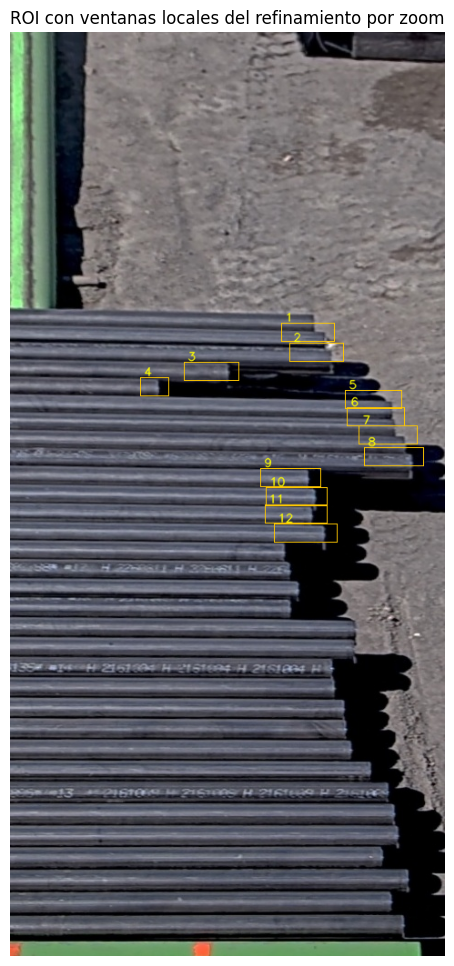

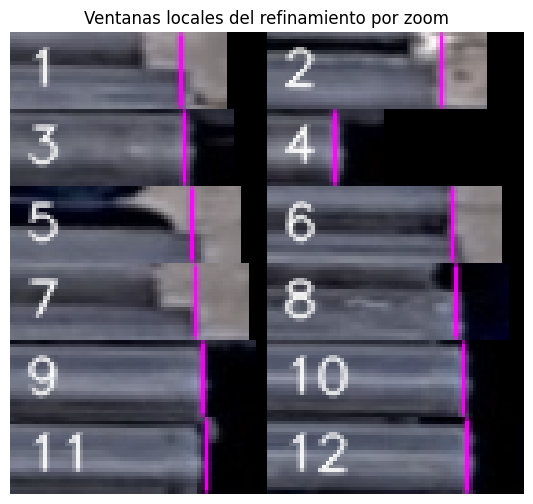

In [704]:
def make_local_window_sheet(roi_bgr, rows_y, x_vals, tube_count, x_search0, x_search1, rows=12):
    from src.cam151_ref_detection.tube_detection_preview import _local_search_bounds

    panels = []
    overlay = roi_bgr.copy()
    total = len(x_vals)
    for idx in range(min(rows, total)):
        yc = int(round(float(rows_y[idx])))
        x_local = float(x_vals[idx])
        lo, hi = _local_search_bounds(x_local, x_search0, x_search1, idx, tube_count)
        py0 = max(0, yc - 10)
        py1 = min(roi_bgr.shape[0] - 1, yc + 10)
        px0 = max(0, lo - 10)
        px1 = min(roi_bgr.shape[1] - 1, hi + 8)
        patch = roi_bgr[py0:py1 + 1, px0:px1 + 1].copy()
        if patch.size == 0:
            continue
        xl = int(round(x_local - px0))
        cv2.line(patch, (max(0, min(patch.shape[1] - 1, xl)), 0), (max(0, min(patch.shape[1] - 1, xl)), patch.shape[0] - 1), (255, 0, 255), 1, cv2.LINE_AA)
        cv2.putText(patch, str(idx + 1), (4, 14), cv2.FONT_HERSHEY_SIMPLEX, 0.45, (255, 255, 255), 1, cv2.LINE_AA)
        panels.append(patch)
        cv2.rectangle(overlay, (px0, py0), (px1, py1), (0, 200, 255), 1)
        cv2.putText(overlay, str(idx + 1), (px0 + 4, max(14, py0 - 2)), cv2.FONT_HERSHEY_SIMPLEX, 0.42, (0, 255, 255), 1, cv2.LINE_AA)

    max_w = max(p.shape[1] for p in panels)
    max_h = max(p.shape[0] for p in panels)
    padded = []
    for p in panels:
        canvas = np.zeros((max_h, max_w, 3), np.uint8)
        canvas[:p.shape[0], :p.shape[1]] = p
        padded.append(canvas)

    rows_out = []
    for i in range(0, len(padded), 2):
        chunk = padded[i:i+2]
        if len(chunk) == 1:
            chunk.append(np.zeros_like(padded[0]))
        rows_out.append(np.hstack(chunk))
    sheet = np.vstack(rows_out)
    return overlay, sheet

local_overlay, local_sheet = make_local_window_sheet(
    warp_crop,
    probe_rows,
    final_x_positions,
    tube_count=len(final_x_positions),
    x_search0=x_search0,
    x_search1=x_search1,
)
show_bgr(local_overlay, 'ROI con ventanas locales del refinamiento por zoom', figsize=(8, 12))
show_bgr(local_sheet, 'Ventanas locales del refinamiento por zoom', figsize=(8, 6))

## 11. Observaciones Actuales

Resumen honesto del estado del pipeline hoy:

- La homografia ya es suficientemente estable para trabajar sobre el paquete derecho.
- El detector de filas en `Y` es bastante mejor que el detector de puntas en `X`.
- Los errores mas duros siguen concentrados en los tubos altos parciales.
- `x_end_estimate` hoy se reporta igual que `x_local`; todavia no hay un estimador independiente completamente robusto del extremo.
- El siguiente paso razonable es mejorar solo esos tubos ambiguos, no reescribir todo el pipeline.